In [2]:
import sys
import os

# Get absolute path of project root (one level up if notebook is inside a folder)
project_root = os.path.abspath(".")

# Add it to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Importing the train.csv file and understanding the shape and datatypes

In [1]:
import numpy as np
import pandas as pd

# =====================================================
# Load Data
# =====================================================
df = pd.read_csv("../data/train.csv")
print("Dataset Shape:", df.shape)
print("\nNumber of Samples:", df.shape[0])
print("Total Columns (including target):", df.shape[1])

print("\nData Types:\n")
print(df.dtypes)


Dataset Shape: (41348, 7)

Number of Samples: 41348
Total Columns (including target): 7

Data Types:

neighbourhood_group        str
room_type                  str
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object


Checking missing values

In [2]:
print(f"\nMissing values:\n{df.isnull().sum()}")


Missing values:
neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
price_class               0
dtype: int64


Filling the missing values for categorical and numerical Features

In [ ]:
# =====================================================
# Define column groups
# =====================================================
cat_cols = ["neighbourhood_group", "room_type"]
num_cols = ["minimum_nights", "amenity_score", "number_of_reviews", "availability_365"]
group_key = "price_class"

# =====================================================
# Step 1: Impute categorical columns — conditional mode
#   - Mode within price_class group
#   - Fallback to global mode if group has no data
# =====================================================
for col in cat_cols:
    group_mode = df.groupby(group_key)[col].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df[col] = df[col].fillna(group_mode)
    
    # Fallback: global mode for any remaining NaNs
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])



# =====================================================
# Step 2: Impute numerical columns — group-wise median
#   - Level 1: median within (neighbourhood_group, room_type, price_class)
#   - Level 2: median within (price_class) as fallback
#   - Level 3: global median as final fallback
# =====================================================
group_levels = [
    [group_key, "neighbourhood_group", "room_type"],  # most specific
    [group_key, "neighbourhood_group"],                # mid-level
    [group_key],                                       # broad
]

for col in num_cols:
    for level in group_levels:
        if not df[col].isnull().any():
            break
        group_median = df.groupby(level)[col].transform("median")
        df[col] = df[col].fillna(group_median)
    
    # Final fallback: global median
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nAfter numerical imputation:")
print(df[num_cols].isnull().sum())

# =====================================================
# Verify: no missing values remain
# =====================================================
print(f"\nTotal missing after imputation: {df.isnull().sum().sum()}")

# =====================================================
# Save processed data
# =====================================================
df.to_csv("processed_data.csv", index=False)
print(f"\nSaved processed_data.csv — Shape: {df.shape}")


After categorical imputation:
neighbourhood_group    0
room_type              0
dtype: int64

After numerical imputation:
minimum_nights       0
amenity_score        0
number_of_reviews    0
availability_365     0
dtype: int64

Total missing after imputation: 0

Saved processed_data.csv — Shape: (41348, 7)


In [6]:
train_df = pd.read_csv("../data/processed_data.csv")
test_df = pd.read_csv("../data/test.csv")

Plotting class distribution for price_class.

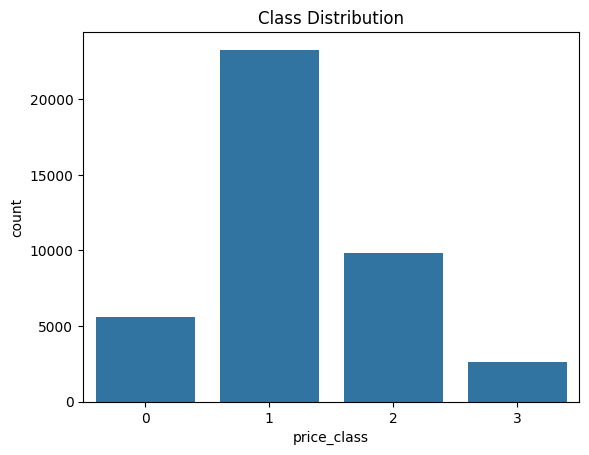

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="price_class", data=train_df)
plt.title("Class Distribution")
plt.show()


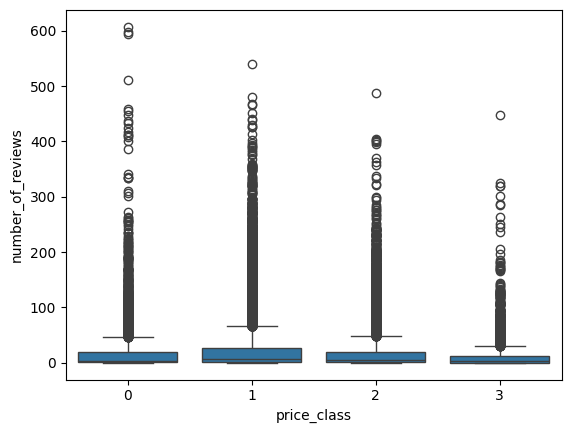

In [11]:
sns.boxplot(x="price_class", y="number_of_reviews", data=train_df)
plt.show()

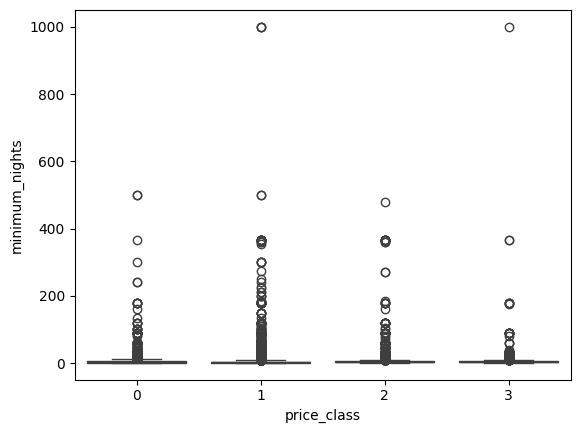

In [12]:
sns.boxplot(x="price_class", y="minimum_nights", data=train_df)
plt.show()

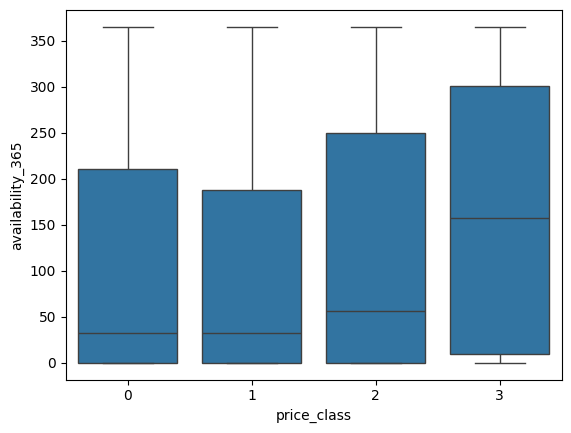

In [13]:
sns.boxplot(x="price_class", y="availability_365", data=train_df)
plt.show()

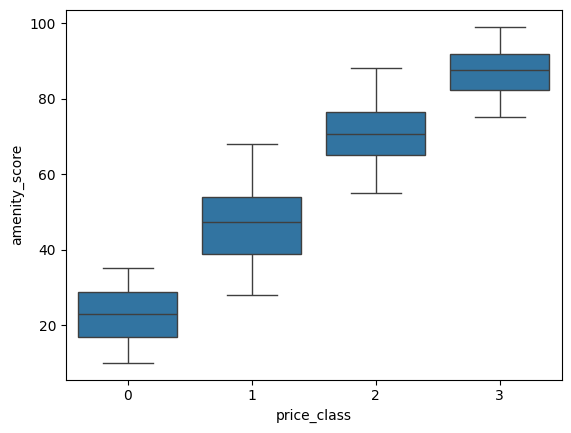

In [14]:
sns.boxplot(x="price_class", y="amenity_score", data=train_df)
plt.show()

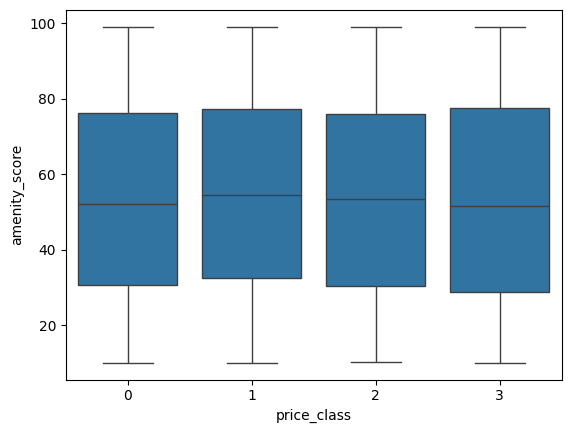

In [26]:
sns.boxplot(x="price_class", y="amenity_score", data=test_df)
plt.show()

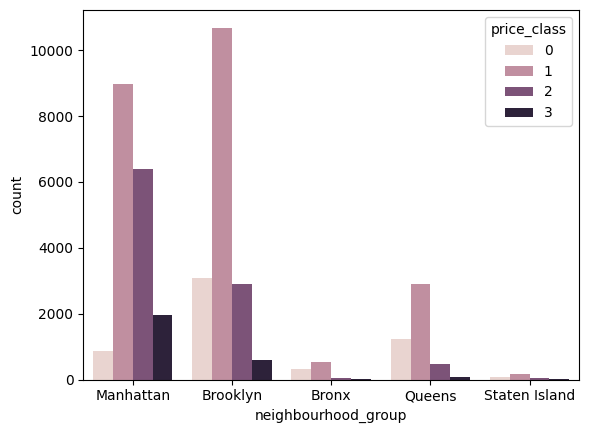

In [15]:
sns.countplot(x="neighbourhood_group", hue="price_class", data=train_df)
plt.show()

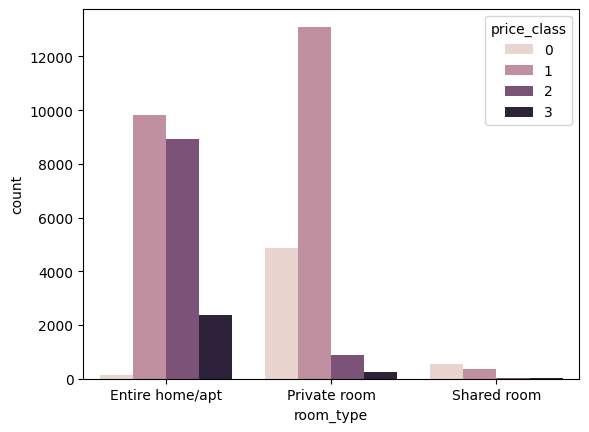

In [16]:
sns.countplot(x="room_type", hue="price_class", data=train_df)
plt.show()

Coorelation Matrix for numerical columns

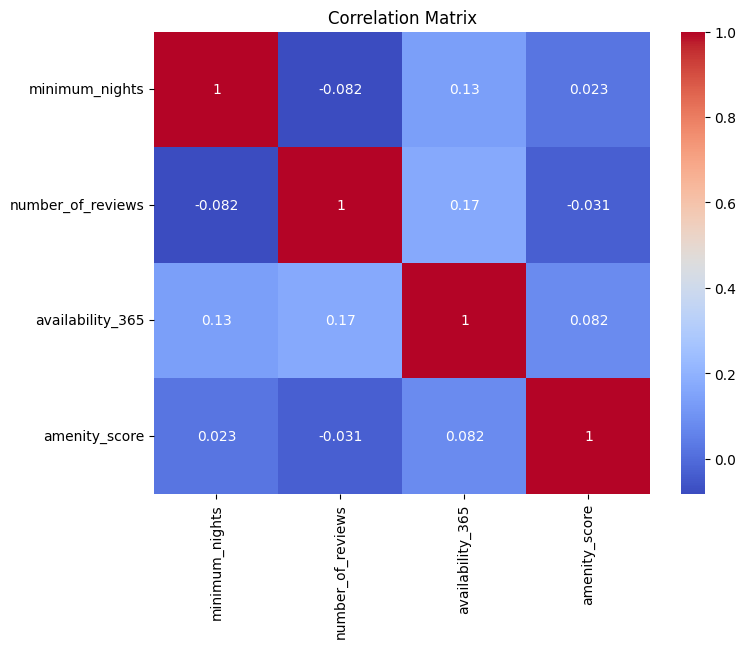

In [32]:
num_cols = ["minimum_nights", "number_of_reviews",
            "availability_365", "amenity_score"]

plt.figure(figsize=(8,6))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Using one hot encoding technique of categorical features

In [8]:
train_df = pd.get_dummies(train_df, columns=["neighbourhood_group", "room_type"], drop_first=True)
test_df = pd.get_dummies(test_df, columns=["neighbourhood_group", "room_type"], drop_first=True)

train_df.shape
test_df.shape

(7297, 11)

Spliting the data before standarization to avoid data leakage

In [9]:
from sklearn.model_selection import train_test_split

# Split first
X = train_df.drop("price_class", axis=1)
y = train_df["price_class"]

X_test= test_df.drop("price_class", axis=1)
y_test = test_df["price_class"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X.shape, y.shape)
print(X_test.shape, y_test.shape)


(41348, 10) (41348,)
(7297, 10) (7297,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [15]:
from sklearn.preprocessing import LabelBinarizer

# Get all unique classes from the full dataset
all_classes = np.unique(y_train)

# Convert y to numpy and one-hot encode with explicit classes
lb = LabelBinarizer()
lb.fit(all_classes)  # Fit on all possible classes first
y_train_encoded = lb.transform(y_train).astype(np.float64)
y_val_encoded = lb.transform(y_val).astype(np.float64)

# Also ensure X is numpy
X_train = X_train.values.astype(np.float64)
X_val = X_val.values.astype(np.float64)


Part B(a): Two-Layer Perceptron Implemented from Scratch (NumPy Only)

In [8]:
# =====================================================
# Activation functions and their derivatives
# =====================================================

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_deriv(a):
    """Derivative given activation output a = sigmoid(z)."""
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivative w.r.t. pre-activation z."""
    return (z > 0).astype(np.float64)

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

In [9]:
# =====================================================
# Weight initialization (He for ReLU, Xavier/Glorot for Sigmoid)
# =====================================================

def init_weights(layers, activation="sigmoid"):
    params = {}
    for l in range(1, len(layers)):
        if activation == "relu":
            scale = np.sqrt(2.0 / layers[l - 1])                # He init
        else:
            scale = np.sqrt(2.0 / (layers[l - 1] + layers[l]))  # Xavier/Glorot init
        params[f"W{l}"] = np.random.randn(layers[l - 1], layers[l]) * scale
        params[f"b{l}"] = np.zeros((1, layers[l]))
    return params

In [10]:
# =====================================================
# Forward Propagation
# =====================================================

def forward(X, params, activation="sigmoid"):
    """
    Two hidden layers with given activation + softmax output layer.
    
    Architecture: X -> [Linear -> Act] -> [Linear -> Act] -> [Linear -> Softmax]
                       ---- Layer 1 ----   ---- Layer 2 ----   --- Output Layer ---
    """
    cache = {"A0": X}
    num_layers = len(params) // 2   # number of (W, b) pairs

    act_fn = sigmoid if activation == "sigmoid" else relu

    # Hidden layers (l = 1, 2)
    for l in range(1, num_layers):
        Z = cache[f"A{l-1}"] @ params[f"W{l}"] + params[f"b{l}"]
        A = act_fn(Z)
        cache[f"Z{l}"] = Z
        cache[f"A{l}"] = A

    # Output layer — softmax
    L = num_layers
    Z = cache[f"A{L-1}"] @ params[f"W{L}"] + params[f"b{L}"]
    A = softmax(Z)
    cache[f"Z{L}"] = Z
    cache[f"A{L}"] = A

    return A, cache

In [11]:
# =====================================================
# Cross-Entropy Loss
# =====================================================

def cross_entropy_loss(Y_hat, Y):
    """
    L = -(1/m) * sum_i sum_j  Y_ij * log(Y_hat_ij)
    """
    m = Y.shape[0]
    log_probs = -np.log(np.clip(Y_hat, 1e-12, 1.0))
    loss = np.sum(Y * log_probs) / m
    return loss

In [12]:
# =====================================================
# Backward Propagation
# =====================================================

def backward(Y, params, cache, activation="sigmoid"):
    """
    Backpropagation through:
      Output layer:  dZ_L = A_L - Y       (softmax + CE combined gradient)
      Hidden layer l: dZ_l = (dZ_{l+1} @ W_{l+1}^T) * g'(Z_l)
      
    Weight gradients:
      dW_l = (1/m) * A_{l-1}^T @ dZ_l
      db_l = (1/m) * sum(dZ_l, axis=0)
    """
    grads = {}
    m = Y.shape[0]
    num_layers = len(params) // 2
    L = num_layers

    # --- Output layer gradient (softmax + cross-entropy combined) ---
    dZ = cache[f"A{L}"] - Y                          # (m, C)
    grads[f"dW{L}"] = cache[f"A{L-1}"].T @ dZ / m
    grads[f"db{L}"] = dZ.mean(axis=0, keepdims=True)

    dA_prev = dZ @ params[f"W{L}"].T

    # --- Hidden layers (iterate backward: L-1, ..., 1) ---
    for l in range(L - 1, 0, -1):
        if activation == "sigmoid":
            # d sigma / dz = a * (1 - a), where a = sigma(z)
            dZ = dA_prev * sigmoid_deriv(cache[f"A{l}"])
        else:
            # d ReLU / dz = 1{z > 0}
            dZ = dA_prev * relu_deriv(cache[f"Z{l}"])

        grads[f"dW{l}"] = cache[f"A{l-1}"].T @ dZ / m
        grads[f"db{l}"] = dZ.mean(axis=0, keepdims=True)

        if l > 1:
            dA_prev = dZ @ params[f"W{l}"].T

    return grads

In [13]:
# =====================================================
# Training Loop — Vanilla Batch Gradient Descent
# =====================================================

def train(X_tr, Y_tr, X_v, Y_v, layer_sizes, activation="sigmoid",
          lr=1.0, epochs=300):

    params = init_weights(layer_sizes, activation)
    history = {"train_acc": [], "val_acc": [],
               "train_loss": [], "val_loss": [],
               "grad_mag_W1": [], "grad_mag_W2": []}

    for epoch in range(epochs):
        # ---- Forward pass ----
        Y_hat_tr, cache = forward(X_tr, params, activation)
        loss_tr = cross_entropy_loss(Y_hat_tr, Y_tr)

        # ---- Backward pass ----
        grads = backward(Y_tr, params, cache, activation)

        # ---- Record gradient magnitudes for hidden layers ----
        history["grad_mag_W1"].append(np.mean(np.abs(grads["dW1"])))
        history["grad_mag_W2"].append(np.mean(np.abs(grads["dW2"])))

        # ---- Parameter update (vanilla gradient descent) ----
        for l in range(1, len(layer_sizes)):
            params[f"W{l}"] -= lr * grads[f"dW{l}"]
            params[f"b{l}"] -= lr * grads[f"db{l}"]

        # ---- Compute metrics ----
        acc_tr = (Y_hat_tr.argmax(axis=1) == Y_tr.argmax(axis=1)).mean()
        Y_hat_v, _ = forward(X_v, params, activation)
        loss_v  = cross_entropy_loss(Y_hat_v, Y_v)
        acc_v   = (Y_hat_v.argmax(axis=1) == Y_v.argmax(axis=1)).mean()

        history["train_acc"].append(acc_tr)
        history["val_acc"].append(acc_v)
        history["train_loss"].append(loss_tr)
        history["val_loss"].append(loss_v)

    return params, history

In [24]:

# =====================================================
# Network Architecture & Training
# =====================================================
num_classes = y_train_encoded.shape[1]  # Use actual encoded shape
input_dim  = X_train.shape[1]
layer_sizes = [input_dim, 64, 32, num_classes]
epochs = 300

# (a) Sigmoid activation
params_sig, hist_sig = train(X_train, y_train_encoded, X_val, y_val_encoded,
                             layer_sizes, activation="sigmoid",
                             lr=0.1, epochs=epochs)

# (b) ReLU activation
params_relu, hist_relu = train(X_train, y_train_encoded, X_val, y_val_encoded,
                               layer_sizes, activation="relu",
                               lr=0.1, epochs=epochs)

In [25]:
# =====================================================
# Final Training & Validation Accuracy
# =====================================================
for name, h in [("Sigmoid", hist_sig), ("ReLU", hist_relu)]:
    print(f"{name:>8s}  |  Train Acc: {h['train_acc'][-1]:.4f}  |  Val Acc: {h['val_acc'][-1]:.4f}")

 Sigmoid  |  Train Acc: 0.6291  |  Val Acc: 0.6247
    ReLU  |  Train Acc: 0.8411  |  Val Acc: 0.8324


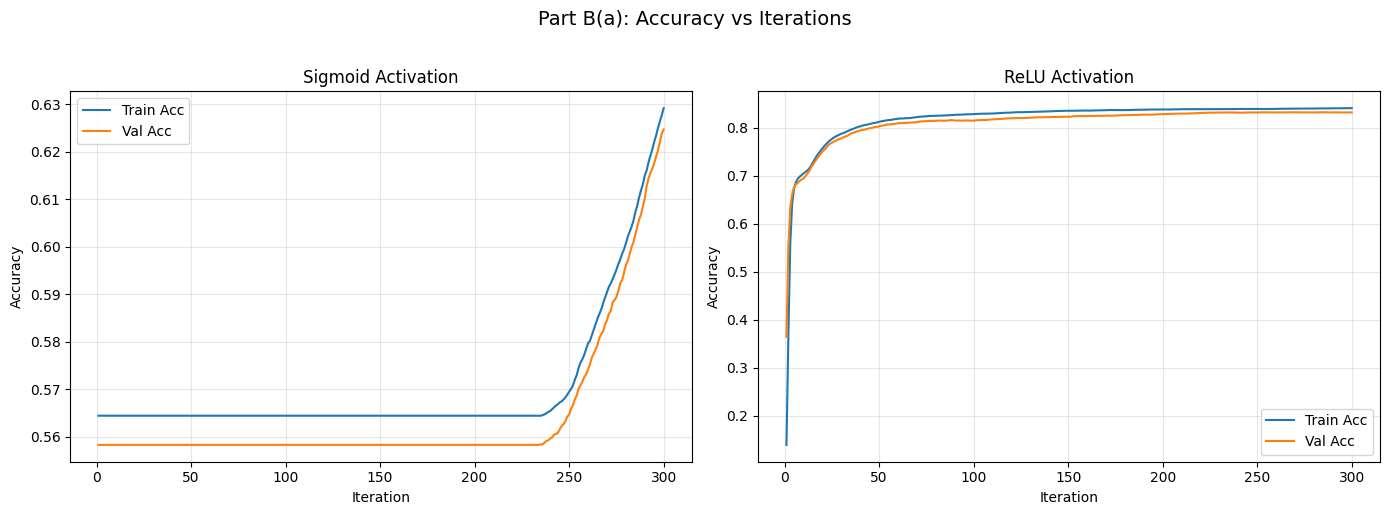

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
iters = range(1, epochs + 1)

# Sigmoid
axes[0].plot(iters, hist_sig["train_acc"], label="Train Acc")
axes[0].plot(iters, hist_sig["val_acc"],   label="Val Acc")
axes[0].set_title("Sigmoid Activation")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ReLU
axes[1].plot(iters, hist_relu["train_acc"], label="Train Acc")
axes[1].plot(iters, hist_relu["val_acc"],   label="Val Acc")
axes[1].set_title("ReLU Activation")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Part B(a): Accuracy vs Iterations", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("part_b_a_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

Part B(b): Gradient Magnitude Comparison Across Layers

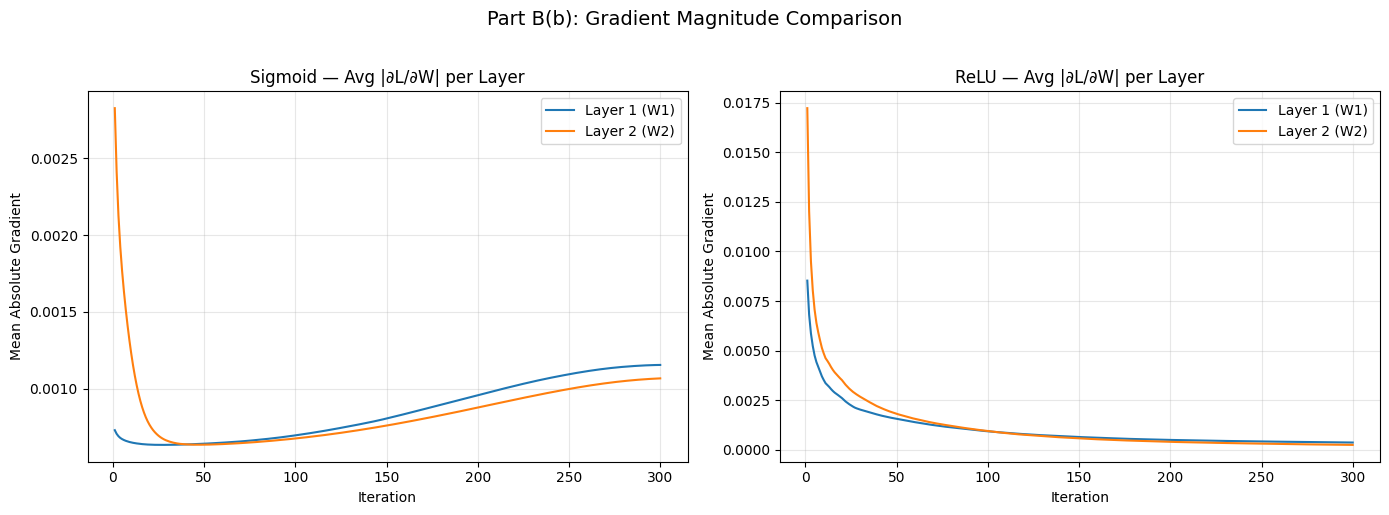

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid
axes[0].plot(iters, hist_sig["grad_mag_W1"], label="Layer 1 (W1)")
axes[0].plot(iters, hist_sig["grad_mag_W2"], label="Layer 2 (W2)")
axes[0].set_title("Sigmoid — Avg |∂L/∂W| per Layer")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Mean Absolute Gradient")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ReLU
axes[1].plot(iters, hist_relu["grad_mag_W1"], label="Layer 1 (W1)")
axes[1].plot(iters, hist_relu["grad_mag_W2"], label="Layer 2 (W2)")
axes[1].set_title("ReLU — Avg |∂L/∂W| per Layer")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean Absolute Gradient")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Part B(b): Gradient Magnitude Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("part_b_b_gradients.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Quantitative comparison: average gradient magnitudes over all iterations
for name, h in [("Sigmoid", hist_sig), ("ReLU", hist_relu)]:
    r = np.mean(h["grad_mag_W2"]) / (np.mean(h["grad_mag_W1"]) + 1e-12)
    print(f"{name:>8s}  |  Mean |∇W1|: {np.mean(h['grad_mag_W1']):.6f}  "
          f"|  Mean |∇W2|: {np.mean(h['grad_mag_W2']):.6f}  "
          f"|  Ratio W2/W1: {r:.3f}")

 Sigmoid  |  Mean |∇W1|: 0.000850  |  Mean |∇W2|: 0.000851  |  Ratio W2/W1: 1.001
    ReLU  |  Mean |∇W1|: 0.001019  |  Mean |∇W2|: 0.001170  |  Ratio W2/W1: 1.148


Part C(b): Gradient-Based Feature Attribution — Implementation (PyTorch)

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# --- Store feature names for later ---
feature_names = [c for c in train_df.columns if c != 'price_class']

# 1. --- Convert to PyTorch tensors ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

num_features = X_train.shape[1]
num_classes = len(np.unique(y))
print(f"Num features: {num_features}, Num classes: {num_classes}")
print(f"Train: {X_train_t.shape}, Val: {X_val_t.shape}")

Num features: 10, Num classes: 4
Train: torch.Size([33078, 10]), Val: torch.Size([8270, 10])


In [17]:
# ============================================================
# 2. MODEL DEFINITION (comparable to Part B)
# ============================================================
class TwoLayerMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim):
        super(TwoLayerMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- Hyperparameters (match Part B) ---
hidden1 = 64
hidden2 = 32
lr = 0.1
epochs = 300

model = TwoLayerMLP(num_features, hidden1, hidden2, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

In [18]:
# ============================================================
# 3. TRAINING
# ============================================================
train_acc_hist = []
val_acc_hist = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # --- Accuracy ---
    with torch.no_grad():
        train_preds = torch.argmax(outputs, dim=1)
        train_acc = (train_preds == y_train_t).float().mean().item()

        model.eval()
        val_outputs = model(X_val_t)
        val_preds = torch.argmax(val_outputs, dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3d}/{epochs}  |  Loss: {loss.item():.4f}  "
              f"|  Train Acc: {train_acc:.4f}  |  Val Acc: {val_acc:.4f}")

print(f"\nFinal  |  Train Acc: {train_acc:.4f}  |  Val Acc: {val_acc:.4f}")

Epoch   1/300  |  Loss: 1.4797  |  Train Acc: 0.0853  |  Val Acc: 0.1233
Epoch  50/300  |  Loss: 0.9626  |  Train Acc: 0.5644  |  Val Acc: 0.5583
Epoch 100/300  |  Loss: 0.6497  |  Train Acc: 0.7578  |  Val Acc: 0.7495
Epoch 150/300  |  Loss: 0.4801  |  Train Acc: 0.8079  |  Val Acc: 0.8019
Epoch 200/300  |  Loss: 0.4051  |  Train Acc: 0.8179  |  Val Acc: 0.8122
Epoch 250/300  |  Loss: 0.3676  |  Train Acc: 0.8378  |  Val Acc: 0.8296
Epoch 300/300  |  Loss: 0.3473  |  Train Acc: 0.8432  |  Val Acc: 0.8366

Final  |  Train Acc: 0.8432  |  Val Acc: 0.8366


In [19]:
# ============================================================
# 4. GRADIENT-BASED FEATURE ATTRIBUTION
# ============================================================


model.eval()
all_gradients = []

for i in range(len(X_train_t)):
    x_single = X_train_t[i:i+1].clone().detach().requires_grad_(True)
    output = model(x_single)
    loss = criterion(output, y_train_t[i:i+1])
    loss.backward()
    all_gradients.append(x_single.grad.detach().abs().numpy())

all_gradients = np.concatenate(all_gradients, axis=0)  # gradient_matrix

# Mean per feature (column j)
feature_importance = np.mean(all_gradients, axis=0)

# ============================================================
# 5. RANKED FEATURE LIST
# ============================================================
ranking = np.argsort(feature_importance)[::-1]

print("\n" + "=" * 60)
print("GRADIENT-BASED FEATURE ATTRIBUTION RANKING")
print("=" * 60)
print(f"{'Rank':<6} {'Feature':<30} {'Mean |∂L/∂x_i|':<15}")
print("-" * 60)
for i, idx in enumerate(ranking):
    print(f"{i+1:<6} {feature_names[idx]:<30} {feature_importance[idx]:.6f}")




GRADIENT-BASED FEATURE ATTRIBUTION RANKING
Rank   Feature                        Mean |∂L/∂x_i| 
------------------------------------------------------------
1      amenity_score                  0.986390
2      room_type_Private room         0.240267
3      neighbourhood_group_Manhattan  0.200703
4      neighbourhood_group_Brooklyn   0.166961
5      neighbourhood_group_Staten Island 0.152994
6      neighbourhood_group_Queens     0.114267
7      room_type_Shared room          0.105880
8      availability_365               0.062798
9      minimum_nights                 0.057332
10     number_of_reviews              0.046395


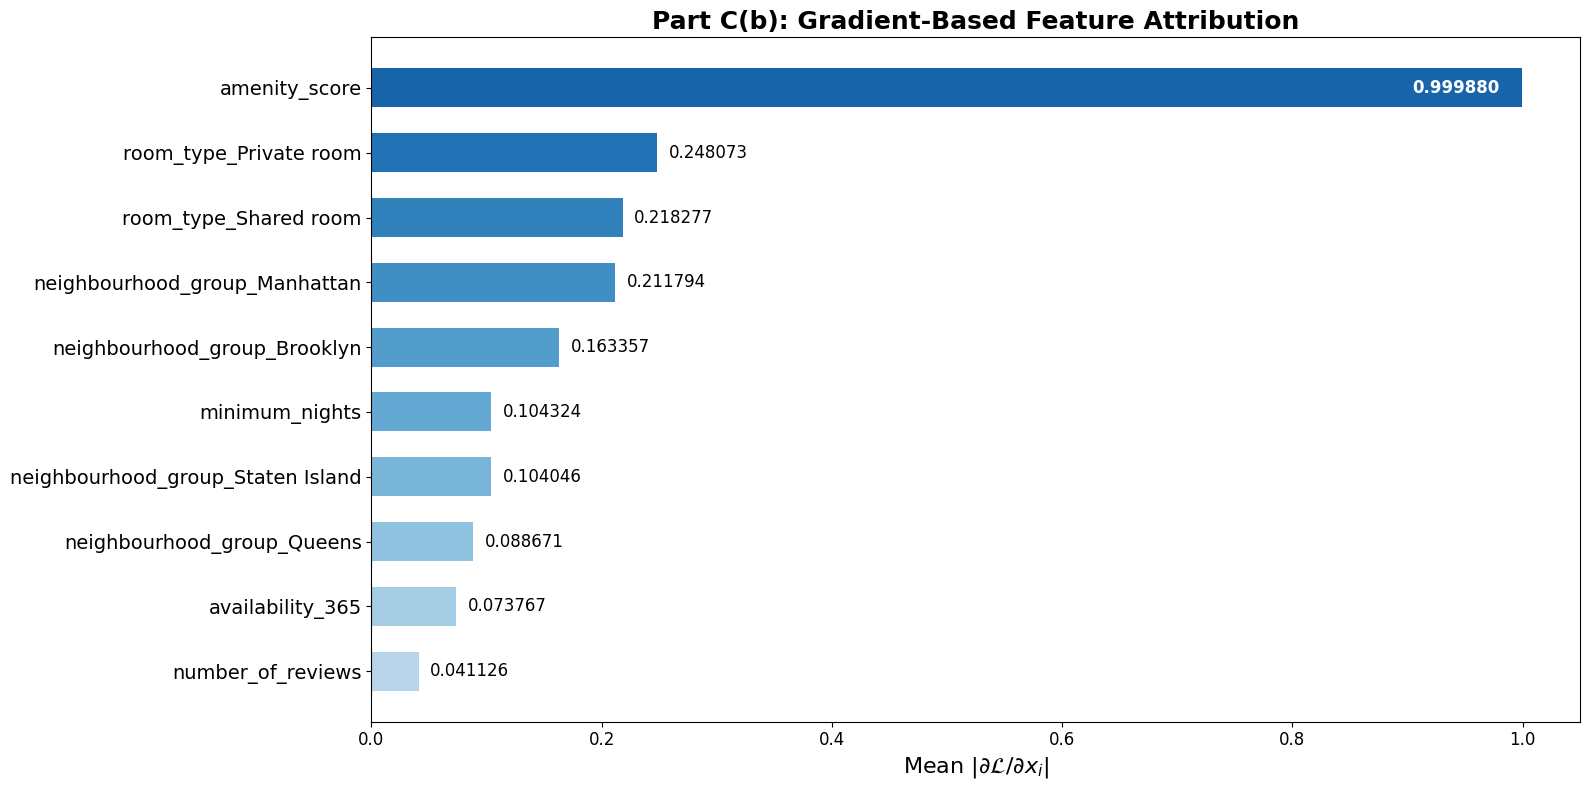

In [65]:
# ============================================================
# 6. VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))
sorted_names = [feature_names[i] for i in ranking]
sorted_scores = feature_importance[ranking]

colors = plt.cm.Blues(np.linspace(0.8, 0.3, len(sorted_names)))
bars = ax.barh(range(len(sorted_names)), sorted_scores, color=colors, height=0.6)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=14)
ax.invert_yaxis()
ax.set_xlabel(r'Mean $|\partial \mathcal{L} / \partial x_i|$', fontsize=16)
ax.set_title('Part C(b): Gradient-Based Feature Attribution', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)

# Place labels inside bars
max_score = sorted_scores[0]
for bar, score in zip(bars, sorted_scores):
    if score > max_score * 0.3:
        ax.text(bar.get_width() - max_score * 0.02, bar.get_y() + bar.get_height()/2,
                f'{score:.6f}', va='center', ha='right', fontsize=12, color='white', fontweight='bold')
    else:
        ax.text(bar.get_width() + max_score * 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.6f}', va='center', fontsize=12)

plt.tight_layout()
plt.show()

Part D: Test Evaluation and Generalization Analysis

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_test = X_test.values.astype(np.float64)

# Convert test data to tensors
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Set model to evaluation mode
model.eval()

# Run inference (no gradient computation needed)
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)

test_preds_np = test_preds.numpy()
y_test_np = np.array(y_test)

# Test Accuracy
test_acc = accuracy_score(y_test_np, test_preds_np)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# Per-class report
print("\nClassification Report:")
print(classification_report(y_test_np, test_preds_np, 
                            target_names=['Budget', 'Moderate', 'Premium', 'Luxury']))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, test_preds_np))

Test Accuracy: 0.3497
Train Accuracy: 0.8432
Val Accuracy:   0.8366
Test Accuracy:  0.3497

Classification Report:
              precision    recall  f1-score   support

      Budget       0.17      0.24      0.20       983
    Moderate       0.57      0.43      0.49      4109
     Premium       0.23      0.28      0.25      1737
      Luxury       0.10      0.16      0.12       468

    accuracy                           0.35      7297
   macro avg       0.27      0.28      0.27      7297
weighted avg       0.40      0.35      0.37      7297


Confusion Matrix:
[[ 239  408  278   58]
 [ 775 1752 1224  358]
 [ 302  731  488  216]
 [  87  191  117   73]]


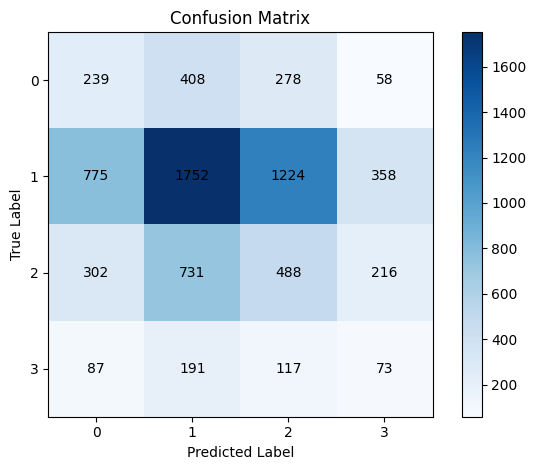

In [28]:
# Compute confusion matrix
cm = confusion_matrix(y_test_np, test_preds_np)

# Plot
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

# Add labels
classes = np.unique(y_test_np)
plt.xticks(classes)
plt.yticks(classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()